# Latent Transforms for Template Similarity

## Why transforms?

`template_similarity()` compares density maps in raw screen space. But when
encoding and retrieval differ by a systematic transform — different screen
sizes, calibration drift between sessions, participant-specific domain shifts,
or contraction/distortion between phases —
raw correlation can underestimate true reinstatement.

`peyesim` supports two families of transform hooks before similarity is
computed:

- **latent transforms** such as PCA, CORAL, and CCA
- **geometric transforms** such as contraction and affine warps

You add them to `template_similarity()` with two arguments; the core API stays
unchanged.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

from peyesim import (
    template_similarity,
    template_similarity_cv,
    coral_transform,
    latent_pca_transform,
    cca_transform,
    contract_transform,
    affine_transform,
)
from peyesim.density import EyeDensity

## A concrete example

Suppose retrieval is a contracted and shifted version of encoding. That is a
better match for a geometric transform than for a latent covariance method, so
we will use `contract_transform()` as the running example:

In [2]:
def make_gaussian_density(mean=(0, 0), cov=None, x=None, y=None):
    """Create an EyeDensity from a 2D Gaussian."""
    if cov is None:
        cov = np.diag([0.2, 0.2])
    if x is None:
        x = np.linspace(-2, 2, 25)
    if y is None:
        y = np.linspace(-2, 2, 25)
    xx, yy = np.meshgrid(x, y, indexing="ij")
    pos = np.stack([xx.ravel(), yy.ravel()], axis=-1)
    z = multivariate_normal.pdf(pos, mean=mean, cov=cov).reshape(xx.shape)
    z = z / z.sum()
    return EyeDensity(x=x, y=y, z=z, sigma=1.0)

rng = np.random.default_rng(901)
ref_means = [rng.uniform(-0.8, 0.8, 2) for _ in range(12)]
ref_cov = np.array([[0.18, 0.02], [0.02, 0.12]])
scale_true = 0.72
shift_true = np.array([0.18, -0.12])

Now create a source set whose densities are shifted and expanded so that the
best alignment is a global contraction plus translation:

In [3]:
ref_tab = pd.DataFrame({
    "id": list(range(len(ref_means))),
    "density": [make_gaussian_density(mean=mu, cov=ref_cov) for mu in ref_means],
})

source_tab = pd.DataFrame({
    "id": list(range(len(ref_means))),
    "density": [
        make_gaussian_density(
            mean=(mu - shift_true) / scale_true,
            cov=ref_cov / (scale_true ** 2),
        )
        for mu in ref_means
    ],
})

## Comparing raw vs. in-sample contract alignment

Without any transform, the contraction distortion reduces similarity:

In [4]:
raw = template_similarity(
    ref_tab, source_tab,
    match_on="id",
    permutations=0,
    method="cosine",
)
raw_mean = raw["eye_sim"].mean()
print(f"Raw mean similarity: {raw_mean:.3f}")

Raw mean similarity: 0.752


Now fit `contract_transform()` on the same matched rows and compare the
in-sample result:

In [5]:
contract_res = template_similarity(
    ref_tab, source_tab,
    match_on="id",
    permutations=0,
    method="cosine",
    similarity_transform=contract_transform,
    similarity_transform_args={"shrink": 1e-6},
)
contract_mean = contract_res["eye_sim"].mean()
print(f"Contract mean similarity: {contract_mean:.3f}")
assert contract_mean > raw_mean, "Contract should improve over raw"

Contract mean similarity: 0.996


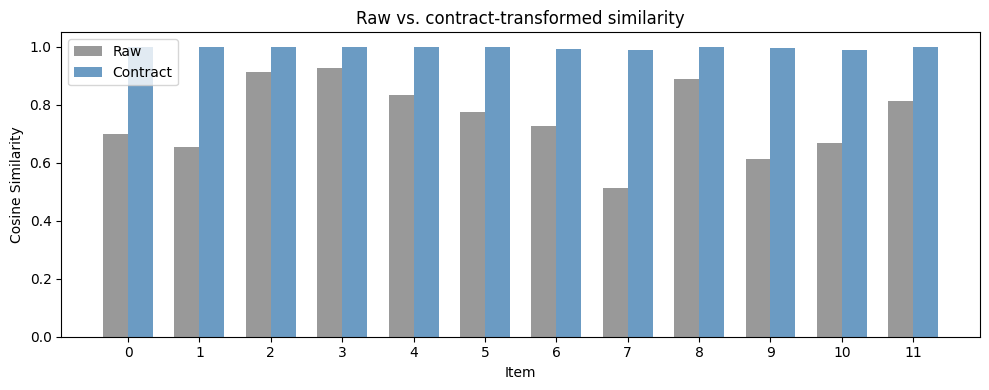

In [6]:
comparison = pd.DataFrame({
    "id": raw["id"],
    "Raw": raw["eye_sim"],
    "Contract": contract_res["eye_sim"],
})

x = np.arange(len(comparison))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, comparison["Raw"], width, label="Raw", color="grey", alpha=0.8)
ax.bar(x + width/2, comparison["Contract"], width, label="Contract", color="steelblue", alpha=0.8)
ax.set_xlabel("Item")
ax.set_ylabel("Cosine Similarity")
ax.set_xticks(x)
ax.set_xticklabels(comparison["id"])
ax.legend()
ax.set_title("Raw vs. contract-transformed similarity")
plt.tight_layout()
plt.show()

The transform recovers substantially higher similarity because the simulated
distortion matches the model. This example is intentionally fit and evaluated
on the same rows, so it shows what the transform can recover, not a
leakage-free effect estimate.

## Leakage and double-dipping

This point matters for any learned transform.

If you call `template_similarity()` with `similarity_transform=...`, the
transform is fit on the same rows that are then scored. That is convenient and
useful for exploration, but it is **not leakage-free**. In other words:

- `template_similarity(..., similarity_transform=None)` is just a direct
  similarity computation and has no fitting-stage leakage issue.
- `template_similarity(..., similarity_transform=coral_transform)` fits the
  transform on the analysis rows themselves. Treat that as exploratory or
  transductive.
- `template_similarity_cv(...)` is the leakage-safe path. It fits the
  transform on training rows only and evaluates similarity on held-out rows.

So the rule is simple:

- use `template_similarity()` for raw similarity, quick checks, and exploratory
  transform probes
- use `template_similarity_cv()` for any analysis you want to interpret
  out-of-sample

The key choice is the held-out unit. Split on the unit that could leak
information across rows, such as participant, scene, or participant-scene key,
not just arbitrary row numbers.

## A leakage-free transform analysis

The held-out API mirrors `template_similarity()`, but it cross-fits the
transform internally.

> **Note:** The current Python implementation of `template_similarity_cv` supports
> the no-transform path (cross-validated permutation baselines). The transform
> path requires fit/apply separation and is tracked for a future release.
> The example below demonstrates the no-transform CV workflow:

In [7]:
cv_result = template_similarity_cv(
    ref_tab, source_tab,
    match_on="id",
    split_on="id",
    n_folds=4,
    permutations=0,
    method="cosine",
)

cv_mean = cv_result["eye_sim"].mean()
print(f"Cross-validated mean similarity: {cv_mean:.3f}")
print(f"Folds: {cv_result['.cv_fold'].unique().tolist()}")

Cross-validated mean similarity: 0.752
Folds: [1, 2, 0, 3]


In `template_similarity_cv()`:

1. held-out rows are assigned by `split_on`
2. held-out `match_on` keys are excluded from transform fitting
3. the transform is fit on training rows only
4. similarity is computed only on the held-out rows

That is the recommended workflow whenever transform fitting is part of the
analysis rather than just a diagnostic.

In practice, use `template_similarity_cv()` whenever you want to report a
transform-based result as part of the substantive analysis. Reserve
`template_similarity(..., similarity_transform=...)` for exploration,
positive controls, and method development.

For retrieval-style analyses, you can also separate the rows used for fitting
and evaluation. For example, fit on positive-control `scene` rows and evaluate
on `delay` rows:

```python
template_similarity_cv(
    ref_tab, source_tab,
    match_on="scene_id",
    split_on=["participant", "scene_id"],
    similarity_transform=contract_transform,
    similarity_transform_args={"shrink": 1e-6},
    fit_source_filter=lambda tab: tab["phase"] == "scene",
    eval_source_filter=lambda tab: tab["phase"] == "delay",
    method="cosine",
)
```

That pattern avoids learning the transform on the same delay rows you are
trying to rescue.

## Available transforms

| Transform | Supervised? | Best for |
|:----------|:------------|:---------|
| `latent_pca_transform()` | No | Dimensionality reduction, mild noise smoothing |
| `contract_transform()` | Yes (matched pairs) | Global contraction/expansion with translation |
| `affine_transform()` | Yes (matched pairs) | Linear geometric distortion, shear, anisotropic scaling |
| `coral_transform()` | No | Device/participant shifts (covariance-level differences) |
| `cca_transform()` | Yes (needs matched pairs) | Item-level alignment when pairings are reliable |

All are passed to `template_similarity()` via the `similarity_transform`
argument:

```python
template_similarity(
    ref_tab, source_tab,
    match_on="id",
    similarity_transform=cca_transform,
    similarity_transform_args={"comps": 10, "shrink": 0.01},
)
```

## Choosing a transform

- **PCA** is the safest default — dimensionality reduction with no assumptions
  about domain differences. Use when you want noise smoothing without domain
  adaptation.
- **Contract** is a good first geometric model when retrieval looks like a
  globally contracted or expanded version of encoding.
- **Affine** is the next step when distortion appears anisotropic or sheared
  rather than purely radial.
- **CORAL** is unsupervised and assumes linear, covariance-level differences
  between domains. Good for calibration drift or different screen sizes.
- **CCA** is supervised and leverages matched pairs to find shared latent axes.
  Set `comps` modestly (5–15) and add `shrink` to stabilize small-N fits.

After the transform, `template_similarity()` still uses your chosen `method`
(cosine, pearson, fisherz, etc.) on the transformed vectors.

## Notes and limitations

- If a transform is fit and evaluated on the same rows via
  `template_similarity()`, the result is exploratory. For leakage-free results,
  use `template_similarity_cv()`.
- Multiscale densities are supported only when all scales share the same grid
  size; otherwise latent transforms will error.
- Regularization (`shrink`) and component count (`comps`) affect stability on
  small-N data — tune as needed.
- CORAL and CCA are linear; they will not correct nonlinear spatial warps.
  `contract_transform()` and `affine_transform()` help with simple geometric
  distortion, but not highly nonlinear warps.
  Keep `comps` low to reduce overfitting, especially with few pairs.
- See the [Overview notebook](01_overview.ipynb) for the core `template_similarity()` workflow
  without transforms.